# ⚙️ Processing — normalização, redução de dimensionalidade e clusters

Este tutorial cobre o módulo **`st.pp.Processing`**: as pipelines de *downstream processing*
que transformam contagens brutas em embeddings e clusters, e as ferramentas de `st.tl` para
ajustar o resultado (juntar clusters, recortar spots).

> **Pré-requisito:** os spots já passaram pelo controle de qualidade.
> Veja [Pre-processing.ipynb](./Pre-processing.ipynb) para essa etapa.

## Dados

Usamos o dataset público de cérebro de camundongo (Visium H&E) distribuído pelo **squidpy**.
Ele já vem com clusters anotados por região anatômica (`obs["cluster"]`), o que dá um
gabarito para comparar contra os clusters que as pipelines produzem.

In [1]:
import os

import anndata as ad
import matplotlib.pyplot as plt
import scanpy as sc

import spatools as st

sc.settings.verbosity = 1

# Aponte para o seu próprio arquivo se quiser rodar com outro dataset.
DATA = os.path.join("data", "anndata", "visium_hne_adata.h5ad")

In [2]:
# Se o arquivo ainda não existe, o squidpy baixa para o caminho acima.
if not os.path.exists(DATA):
    import squidpy as sq
    os.makedirs(os.path.dirname(DATA), exist_ok=True)
    sq.datasets.visium_hne_adata(path=DATA)

adata = sc.read_h5ad(DATA)
adata

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

## 1. Recuperando as contagens brutas

As pipelines de `Processing` esperam **contagens inteiras**, porque tanto a normalização por
resíduos de Pearson quanto a `normalize_total` + `log1p` partem do dado cru. Esta cópia do
`visium_hne` já vem log-normalizada em `.X`, mas guarda as contagens originais em `.raw`.

In [3]:
print("X   (processado):", adata.X.min(), "->", adata.X.max())
print("raw (contagens) :", adata.raw.X.min(), "->", adata.raw.X.max())

X   (processado): 0.0 -> 8.859275
raw (contagens) : 0.0 -> 23703.0


In [4]:
counts = ad.AnnData(
    X=adata.raw.X.copy(),
    obs=adata.obs[["cluster"]].copy(),
    var=adata.raw.var.copy(),
    obsm={"spatial": adata.obsm["spatial"].copy()},
    uns={"spatial": adata.uns["spatial"]},
)
counts.var_names_make_unique()
counts

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'

## 2. Quais pipelines existem?

`Processing` é um **registro**: cada pipeline é uma função decorada com
`@Processing.register("nome")`. Isso permite adicionar workflows novos sem alterar o pacote.

In [5]:
list(st.pp.Processing.pipelines)

['pearson_PCA', 'lognorm', 'scVI_pearson']

## 3. Pipeline `lognorm`

O caminho clássico do scanpy:

`normalize_total` → `log1p` → seleção de HVGs → (opcional) subset → `scale` → `pca`

Repare que ela **para na PCA**: não calcula vizinhos, UMAP nem clusters. Isso é proposital —
`lognorm` serve como base para você escolher os próprios parâmetros de vizinhança.

In [6]:
adata_ln = st.pp.Processing.run(
    "lognorm",
    counts.copy(),
    n_hvg=2000,
    subset_hvg=True,   # mantém no objeto apenas os 2000 genes mais variáveis
)
adata_ln

/usr/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 2688 × 2000
    obs: 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'spatial', 'log1p', 'hvg', 'pca'
    obsm: 'spatial', 'X_pca'
    varm: 'PCs'

In [7]:
# Completando o que a lognorm deliberadamente não faz
sc.pp.neighbors(adata_ln, n_pcs=30)
sc.tl.umap(adata_ln)
sc.tl.leiden(adata_ln, resolution=0.5, key_added="leiden_lognorm", flavor="igraph", n_iterations=2)

adata_ln.obs["leiden_lognorm"].value_counts().sort_index()

leiden_lognorm
0     373
1      53
2     177
3     141
4     504
5     224
6     334
7     319
8     259
9     211
10     93
Name: count, dtype: int64

## 4. Pipeline `pearson_PCA`

Normaliza por **resíduos de Pearson** (`sc.experimental.pp.normalize_pearson_residuals`), que
estabiliza a variância sem precisar de log-transformação, e já entrega o pacote completo:
PCA → vizinhos → UMAP → Leiden.

Os parâmetros `n_pcs` e `resolution` são repassados direto para a pipeline.

In [8]:
adata_pr = st.pp.Processing.run(
    "pearson_PCA",
    counts.copy(),
    n_pcs=30,
    resolution=0.5,
    n_hvg=2000,
)
adata_pr

/mnt/SATA/spatools/spatools/processing/processing_.py:75: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=resolution, flavor="leidenalg")


AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'cluster', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'spatial', 'pearson_residuals_normalization', 'pca', 'neighbors', 'hvg', 'umap', 'leiden'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

## 5. Comparando as duas normalizações

Mesmo dado, mesma resolução de Leiden — o que muda é só a normalização.

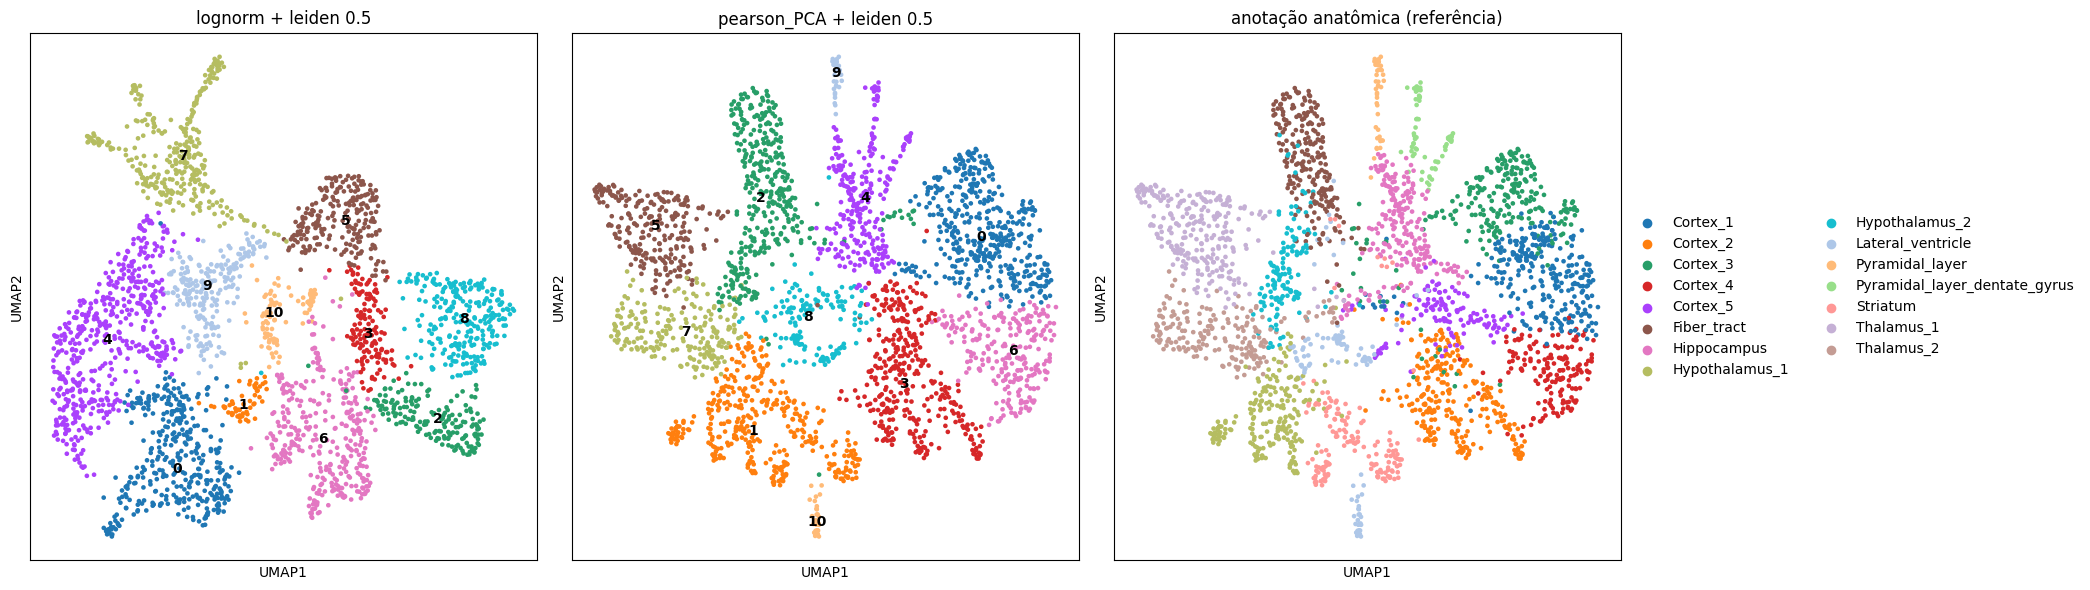

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

sc.pl.umap(adata_ln, color="leiden_lognorm", ax=axes[0], show=False,
           title="lognorm + leiden 0.5", legend_loc="on data")
sc.pl.umap(adata_pr, color="leiden", ax=axes[1], show=False,
           title="pearson_PCA + leiden 0.5", legend_loc="on data")
sc.pl.umap(adata_pr, color="cluster", ax=axes[2], show=False,
           title="anotação anatômica (referência)")

plt.tight_layout()
plt.show()

In [10]:
# Quantos clusters cada caminho produziu
print("lognorm     :", adata_ln.obs["leiden_lognorm"].nunique(), "clusters")
print("pearson_PCA :", adata_pr.obs["leiden"].nunique(), "clusters")
print("anotação    :", adata_pr.obs["cluster"].nunique(), "regiões")

lognorm     : 11 clusters
pearson_PCA : 11 clusters
anotação    : 15 regiões


### E no espaço físico do tecido

`spatial_plot` desenha **um painel por valor de `sample_key`**, e para cada painel busca a
imagem em `adata.uns["spatial"][valor]`. Ou seja: os valores dessa coluna precisam ser
exatamente as chaves de `uns["spatial"]`. Aqui há uma amostra só.

chaves em uns['spatial']: ['V1_Adult_Mouse_Brain']


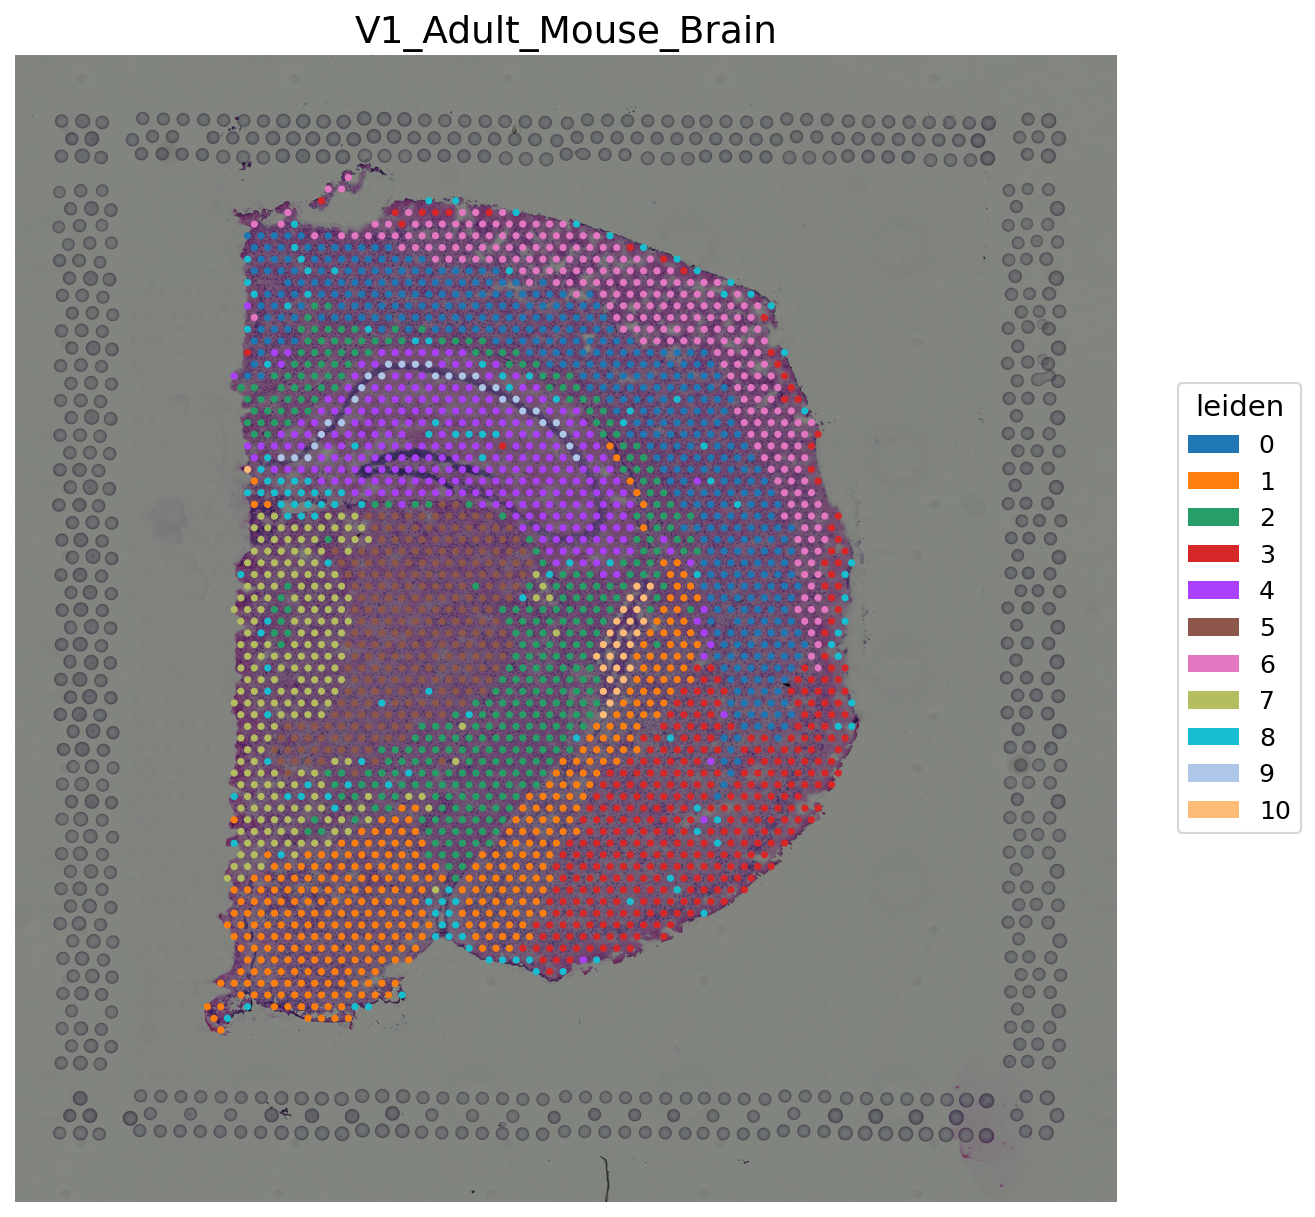

In [11]:
print("chaves em uns['spatial']:", list(adata_pr.uns["spatial"]))

adata_pr.obs["sample"] = list(adata_pr.uns["spatial"])[0]
adata_pr.obs["sample"] = adata_pr.obs["sample"].astype("category")

st.pl.spatial_plot(
    adata_pr,
    group="leiden",
    sample_key="sample",
    spot_size=12,
    figsize=(8, 8),
)

> Em um objeto com várias amostras concatenadas, passe a coluna que identifica cada uma
> (`"batch"`, `"library_id"`, …) e ganhe um painel por amostra. Isso é explorado a fundo em
> [ploting.ipynb](./ploting.ipynb).

## 6. `merge_clusters` — agrupando clusters

Leiden costuma fragmentar uma mesma estrutura biológica em vários clusters. `merge_clusters`
cria uma **nova coluna** com o agrupamento, preservando a original intacta.

O `rename_dict` mapeia rótulo antigo → rótulo novo: todos os clusters que recebem o mesmo
nome viram um só.

> ⚠️ **Atenção ao rótulo final.** A função não mantém os nomes que você escreveu no
> `rename_dict`. Depois de agrupar, ela ordena os rótulos resultantes em ordem
> **lexicográfica** e renumera tudo para `"0"`, `"1"`, `"2"`… Como a ordenação é de texto,
> `"10"` vem antes de `"5"`, e os nomes que você deu (`"Cortex"`) vão para o fim da fila.
> O agrupamento está correto; o **número** do cluster novo não tem relação com o antigo.
> A célula seguinte mostra o mapeamento de fato aplicado.

In [12]:
# Quais clusters do Leiden caem em cada região anotada?
import pandas as pd

pd.crosstab(adata_pr.obs["leiden"], adata_pr.obs["cluster"]).style.background_gradient(
    cmap="Blues", axis=1
)

cluster,Cortex_1,Cortex_2,Cortex_3,Cortex_4,Cortex_5,Fiber_tract,Hippocampus,Hypothalamus_1,Hypothalamus_2,Lateral_ventricle,Pyramidal_layer,Pyramidal_layer_dentate_gyrus,Striatum,Thalamus_1,Thalamus_2
leiden,,,,,,,,,,,,,,,
0,211,0,204,0,0,0,14,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,204,2,20,0,0,142,0,1
2,0,0,21,0,0,219,0,0,107,12,0,0,3,1,0
3,1,249,10,6,79,0,2,0,0,3,0,0,2,0,0
4,1,2,3,0,3,3,181,0,0,0,11,68,5,0,0
5,0,0,0,0,0,0,0,0,1,0,0,0,0,246,0
6,60,0,0,158,25,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,1,19,0,0,0,0,10,175
8,11,5,6,0,22,4,25,3,4,42,1,0,1,4,16


In [13]:
rename_dict = {
    "0": "Cortex",
    "1": "Cortex",
    "2": "Cortex",
    "3": "Thalamus",
    "4": "Thalamus",
}

adata_pr = st.tl.merge_clusters(
    adata_pr,
    clusters_col="leiden",
    rename_dict=rename_dict,
    new_clusters_col="leiden_merged",
)

adata_pr.obs["leiden_merged"].value_counts()

leiden_merged
6    1162
7     629
1     247
2     243
3     205
4     144
5      30
0      28
Name: count, dtype: int64

In [14]:
# Mapeamento efetivo: repare que 0, 1 e 2 caíram no mesmo grupo (assim como 3 e 4),
# mas o rótulo final foi renumerado.
(
    adata_pr.obs[["leiden", "leiden_merged"]]
    .drop_duplicates()
    .sort_values("leiden", key=lambda s: s.astype(int))
    .reset_index(drop=True)
)

,leiden,leiden_merged
0,0,6
1,1,6
2,2,6
3,3,7
4,4,7
5,5,1
6,6,2
7,7,3
8,8,4
9,9,5


## 7. `remove_spots` — recorte espacial

Serve para tirar artefatos de borda, bolhas ou regiões fora do tecido. O parâmetro `type`
aceita:

| `type` | efeito |
|---|---|
| `"x_min"`, `"x_max"`, `"y_min"`, `"y_max"` | remove os `n_spots` extremos naquele eixo |
| `"x"` / `"y"` | remove os extremos dos **dois** lados do eixo |
| `"all"` | remove os extremos dos quatro lados |
| `"lower"` / `"upper"` | remove `n_spots` dentro de uma janela delimitada por `x_minimo`/`x_maximo`/`y_minimo`/`y_maximo` |

A função devolve uma **cópia** — o objeto original não é alterado.

In [15]:
print("antes :", adata_pr.n_obs, "spots")

recortado = st.tl.remove_spots(adata_pr, type="all", n_spots=25)
print("depois:", recortado.n_obs, "spots  (4 x 25 extremos removidos)")

antes : 2688 spots
depois: 2593 spots  (4 x 25 extremos removidos)


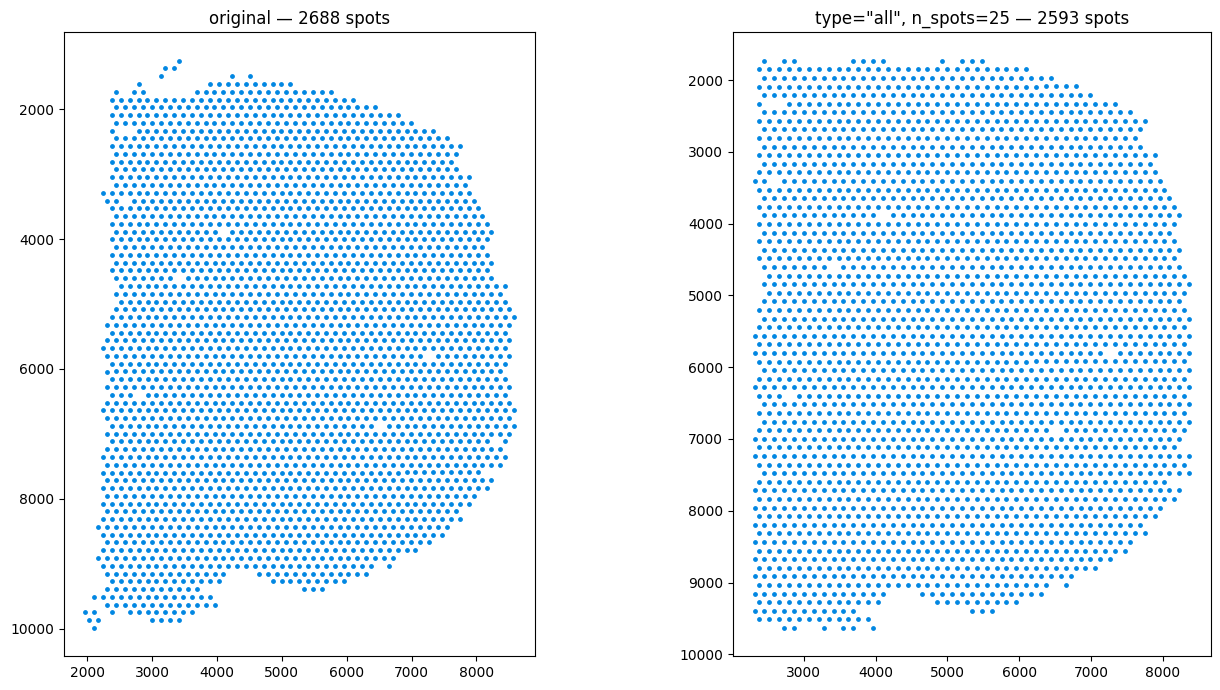

In [16]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, obj, titulo in zip(axes, [adata_pr, recortado], ["original", 'type="all", n_spots=25']):
    xy = np.asarray(obj.obsm["spatial"])
    ax.scatter(xy[:, 0], xy[:, 1], s=6, c="#0187E2")
    ax.set_title(f"{titulo} — {obj.n_obs} spots")
    ax.invert_yaxis()
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

In [17]:
# Recorte por janela: entre os spots com x > 4000, remove os 100 de menor y
janela = st.tl.remove_spots(adata_pr, type="upper", n_spots=100, x_minimo=4000)
print("removidos:", adata_pr.n_obs - janela.n_obs, "spots")

removidos: 100 spots


## 8. Ferramentas complementares

### `translate_anndata_genes` — Ensembl ID → símbolo

Muitos objetos Visium vêm com `var_names` no formato `ENSG…`/`ENSMUSG…`, o que quebra
qualquer busca por nome de gene. A função consulta o **mygene** e troca o índice pelos
símbolos, guardando os IDs originais em `var["gene_ids"]` e resolvendo duplicatas.

Como ela faz uma requisição de rede, a célula abaixo fica como referência (não executada):

```python
adata = st.tl.translate_anndata_genes(
    adata,
    col=None,          # None = usa o var.index; ou o nome da coluna com os Ensembl IDs
    species="mouse",   # "human" é o padrão
    inplace=True,
)
adata.var[["gene_ids", "gene_symbol"]].head()
```

### `SelectionTool` — seleção manual por laço

Ferramenta **interativa** (abre uma janela matplotlib), então não roda dentro de um notebook.
Use o script [manual_cuts.py](./manual_cuts.py):

```python
from spatools.tools.tl import SelectionTool

tool = SelectionTool("/caminho/para/amostras")   # arquivo .h5ad ou pasta com vários
adata = tool.run()

adata.obs["selected_area"].value_counts()
```

Atalhos principais: **clique e arraste** desenha o laço · `a` salva a seleção ·
`c` limpa · `w` grava o `.h5ad` · `q` sai · `z`/`x` tamanho do spot · `v` cor ·
scroll ajusta a transparência.

## Próximos passos

- [ploting.ipynb](./ploting.ipynb) — visualizar o que foi produzido aqui
- [clustering_correlation_analysis.ipynb](./clustering_correlation_analysis.ipynb) — medir
  colocalização entre os clusters (z-score de vizinhança)